<div style="
    font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #38668d, #46a6ab);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2 style="margin:0;">🛠️ Exploratory Data Analysis (EDA)</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="
    font-size:17px;
    color:#2c3e50;
    line-height:1.6;
    margin:0;
">
The dataset underwent a comprehensive preprocessing pipeline to ensure quality and consistency. 
Missing values were handled appropriately, categorical variables were encoded into machine-readable formats, 
and numerical features were scaled to standardize their ranges. These steps improved data integrity and 
helped optimize downstream model performance.
</p>

</div>

</div>

- Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from sklearn.preprocessing import StandardScaler , OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

sns.set_theme()

- Load Data

In [3]:
df = pd.read_csv("../data/House Prices Dataset.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


- Understanding the Data

In [4]:
print("Shape:", df.shape)

Shape: (1460, 81)


In [5]:
print("Columns:")
df.columns

Columns:


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
print("Info:")
df.info()

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond  

In [7]:
print("Describe:")
df.describe()

Describe:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


- Missing Values

Missing Values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


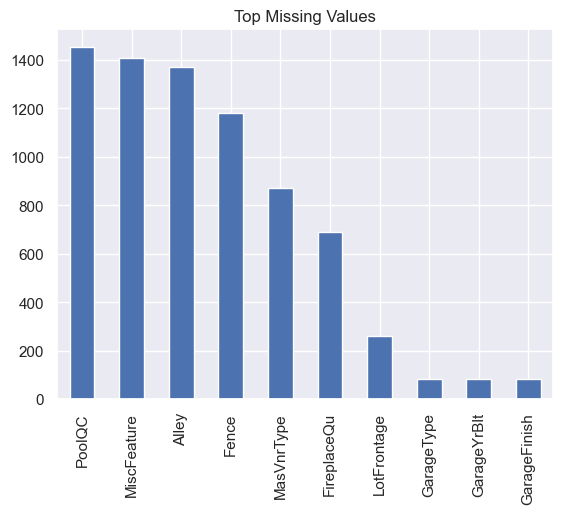

In [8]:
missing = df.isnull().sum()

# show the columns that have nulls
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing Values:")
print(missing)

# Simple plot to show the number of nulls in every column 
missing.head(10).plot(kind="bar")
plt.title("Top Missing Values")
plt.show()

- Distribution (Target Variable => price)

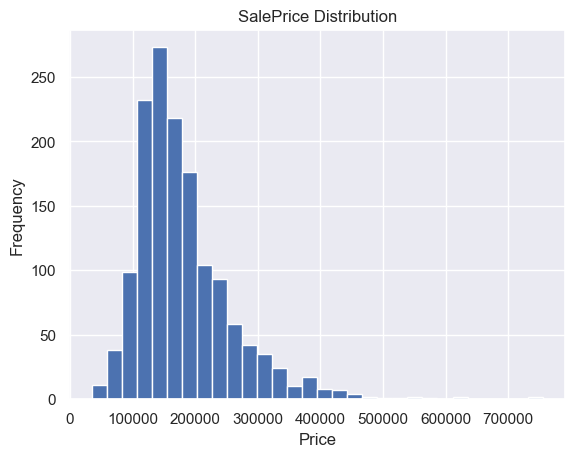

In [9]:
plt.hist(df["SalePrice"], bins=30)
plt.title("SalePrice Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

- Correlation


To show the relationship between features and the price (target)

Top 20 Correlations with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
Name: SalePrice, dtype: float64


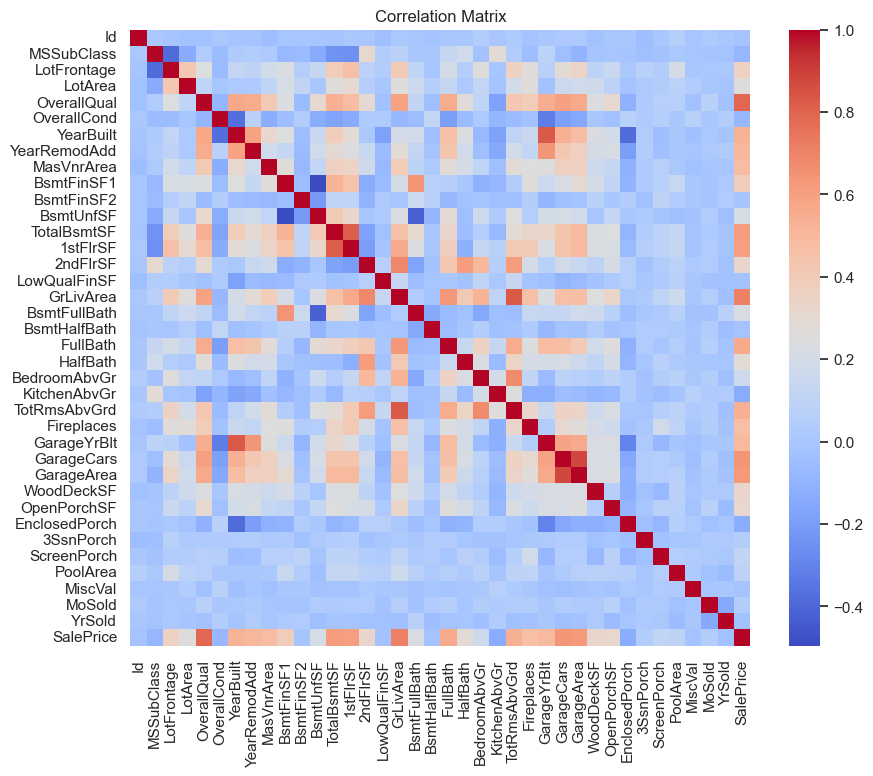

In [10]:
corr = df.corr(numeric_only=True)

# أعلى correlation مع السعر
top_corr = corr["SalePrice"].sort_values(ascending=False)

print("Top 20 Correlations with SalePrice:")
print(top_corr.head(20))

# Heatmapclas
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

- Visualization => The relation between the important features and the price (target)


1- Overall Quality vs Price

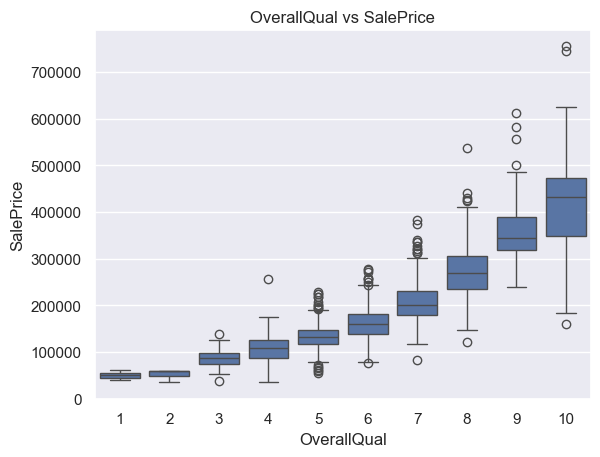

In [11]:
sns.boxplot(x="OverallQual", y="SalePrice", data=df)
plt.title("OverallQual vs SalePrice")
plt.show()

the relationship here is when the Quality increse the price increace and the boxplot show that correctly 

2- Living Area vs Price

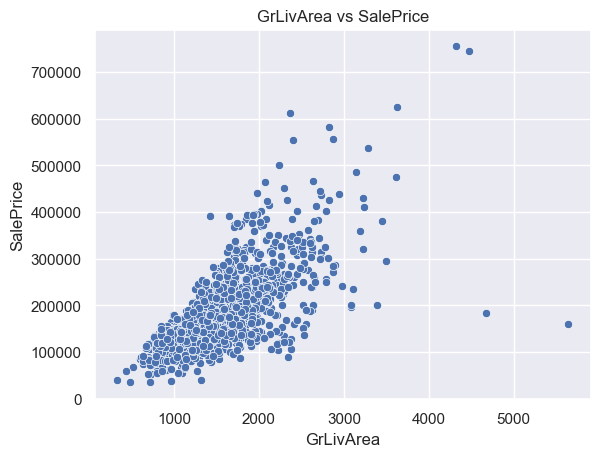

In [12]:
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.title("GrLivArea vs SalePrice")
plt.show()

the relationship here is when the Area increse the price increace and the scatter show that correctly 

## 3- Garage vs Price

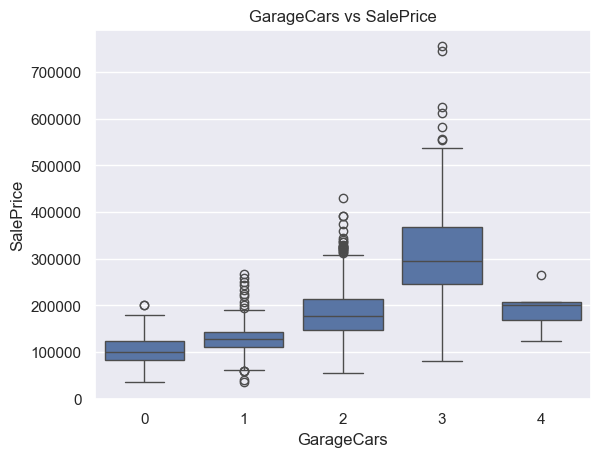

In [13]:
sns.boxplot(x="GarageCars", y="SalePrice", data=df)
plt.title("GarageCars vs SalePrice")
plt.show()

<div style="font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #4facfe, #00f2fe);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2>🧹 Preprocessing Section</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="font-size:17px; color:#2c3e50;">
Data was cleaned, missing values handled, categorical features encoded, and numerical features scaled to prepare the dataset for modeling.
</p>

</div>

</div>

In [14]:
df = pd.read_csv('../data/House Prices Dataset.csv')
print(f'rows : {df.shape[0]} || columns : {df.shape[1]}')
print(f'nulls in Price target column : {df['SalePrice'].isna().sum()} ')

rows : 1460 || columns : 81
nulls in Price target column : 0 


In [15]:

kitchen_andExter_order = [['Fa','TA','Gd','Ex'] , ['Fa','TA','Gd','Ex'] ] # ordinal data (ranks)

# ================= cat data ======================== 

cat_features_all = [
    'Neighborhood',
    'HouseStyle',
    'Foundation',
    'KitchenQual',
    'ExterQual'
]


cat_features_ohe = [
    'Neighborhood',
    'HouseStyle',
    'Foundation', ]


cat_features_ordencd = [
   'KitchenQual',
    'ExterQual'
     ]


In [16]:
# ================== correlation ======================== 
corr = df.corr(numeric_only=True)
top_corr = corr["SalePrice"].sort_values(ascending=False).reset_index()

# top 5 categorical columns 
print("Top 15 Correlations with SalePrice:")
print(top_corr.head(16))
numeric_data = top_corr.head(16).iloc[:,0].tolist()



Top 15 Correlations with SalePrice:
           index  SalePrice
0      SalePrice   1.000000
1    OverallQual   0.790982
2      GrLivArea   0.708624
3     GarageCars   0.640409
4     GarageArea   0.623431
5    TotalBsmtSF   0.613581
6       1stFlrSF   0.605852
7       FullBath   0.560664
8   TotRmsAbvGrd   0.533723
9      YearBuilt   0.522897
10  YearRemodAdd   0.507101
11   GarageYrBlt   0.486362
12    MasVnrArea   0.477493
13    Fireplaces   0.466929
14    BsmtFinSF1   0.386420
15   LotFrontage   0.351799


In [17]:
# ================= dropping  ====================== 
all_data = cat_features_all + numeric_data
df = df[all_data ]
print('data after droping unesential columns : ')
print(f'rows : {df.shape[0]} || columns : {df.shape[1]}')

data after droping unesential columns : 
rows : 1460 || columns : 21


In [18]:
# ============== unique values checking ===================== 
for i in cat_features_all :
    print(f'unique values in {i} column : {df[i].unique()}')
    print(f'unique values number in {i} column : {df[i].nunique()}')

unique values in Neighborhood column : <StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str
unique values number in Neighborhood column : 25
unique values in HouseStyle column : <StringArray>
['2Story', '1Story', '1.5Fin', '1.5Unf', 'SFoyer', 'SLvl', '2.5Unf', '2.5Fin']
Length: 8, dtype: str
unique values number in HouseStyle column : 8
unique values in Foundation column : <StringArray>
['PConc', 'CBlock', 'BrkTil', 'Wood', 'Slab', 'Stone']
Length: 6, dtype: str
unique values number in Foundation column : 6
unique values in KitchenQual column : <StringArray>
['Gd', 'TA', 'Ex', 'Fa']
Length: 4, dtype: str
unique values number in KitchenQual column : 4
unique values in ExterQual column : <StringArray>
['Gd', 'TA', 'Ex', 'Fa']
Len

In [19]:
# ================ Splitting ========================== 
X = df.drop('SalePrice' , axis=1)
y = df['SalePrice']
x_tr , x_test , y_tr , y_test = train_test_split(X , y , test_size= 0.2 , random_state= 40)

print(f'shape of train data {x_tr.shape}')
print(f'shape of test data {x_test.shape}')

shape of train data (1168, 20)
shape of test data (292, 20)


In [20]:
int_data = []
float_data = []
for i in numeric_data :
    if i != 'SalePrice' : # sale price now is the target we must skip it from loop (it's not in x_tr)
        typee = x_tr[i].dtype
        print(f'{i} : {typee} ')
        if typee == 'int64' :
            int_data.append(i)
        else :
            float_data.append(i)

print(f'int data : {int_data} \n {x_tr[int_data]}' )
print(f'float data : {float_data} \n {x_tr[float_data]}' )
# now i know that all data is int the float is just a number .0

OverallQual : int64 
GrLivArea : int64 
GarageCars : int64 
GarageArea : int64 
TotalBsmtSF : int64 
1stFlrSF : int64 
FullBath : int64 
TotRmsAbvGrd : int64 
YearBuilt : int64 
YearRemodAdd : int64 
GarageYrBlt : float64 
MasVnrArea : float64 
Fireplaces : int64 
BsmtFinSF1 : int64 
LotFrontage : float64 
int data : ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'Fireplaces', 'BsmtFinSF1'] 
       OverallQual  GrLivArea  GarageCars  GarageArea  TotalBsmtSF  1stFlrSF  \
609             4       1029           1         261         1029      1029   
1361            7       1530           2         430         1530      1530   
1076            5       1466           2         566          796      1096   
1138            6       1567           2         714         1567      1567   
1159            6       1876           2         540          901       943   
...           ...        ...        

In [21]:
median_cols = [
    'LotFrontage',
    'MasVnrArea',
    'GarageYrBlt',
    'GrLivArea',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'BsmtFinSF1',
    'YearBuilt',
    'YearRemodAdd'
]

mode_cols = [
    'GarageCars',
    'FullBath',
    'TotRmsAbvGrd',
    'Fireplaces',
    'OverallQual'
]
print(f'data to be imputed with mode : \n {df[mode_cols]}') # mode is better with those columns 

for i in median_cols : 
   print(f'{i} column value counts \n {df[i].value_counts()} \n ============================================== \n')

data to be imputed with mode : 
       GarageCars  FullBath  TotRmsAbvGrd  Fireplaces  OverallQual
0              2         2             8           0            7
1              2         2             6           1            6
2              2         2             6           1            7
3              3         1             7           1            7
4              3         2             9           1            8
...          ...       ...           ...         ...          ...
1455           2         2             7           1            6
1456           2         2             7           2            6
1457           1         2             9           2            7
1458           1         1             5           0            5
1459           1         1             6           0            5

[1460 rows x 5 columns]
LotFrontage column value counts 
 LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
138.0      1
160.0      1


In [22]:
print('train data : ')
x_tr.head()

train data : 


,Neighborhood,HouseStyle,Foundation,KitchenQual,ExterQual,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,GarageYrBlt,MasVnrArea,Fireplaces,BsmtFinSF1,LotFrontage
609,Sawyer,1Story,CBlock,TA,TA,4,1029,1,261,1029,1029,1,5,1961,1961,1961.0,192.0,0,903,61.0
1361,StoneBr,1Story,PConc,Gd,Gd,7,1530,2,430,1530,1530,2,7,2005,2005,2005.0,16.0,1,1274,124.0
1076,OldTown,1.5Fin,CBlock,Gd,TA,5,1466,2,566,796,1096,2,7,1936,1989,1950.0,0.0,1,626,60.0
1138,Mitchel,1Story,PConc,Gd,TA,6,1567,2,714,1567,1567,2,5,1977,1977,1977.0,0.0,2,1567,NaN
1159,NWAmes,2Story,CBlock,Gd,Gd,6,1876,2,540,901,943,2,8,1974,1974,1974.0,270.0,1,442,76.0


In [23]:
print('test data : ')
x_test.head()

test data : 


,Neighborhood,HouseStyle,Foundation,KitchenQual,ExterQual,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,GarageYrBlt,MasVnrArea,Fireplaces,BsmtFinSF1,LotFrontage
1258,Gilbert,SLvl,PConc,Gd,Gd,7,1166,2,400,856,1166,2,5,2005,2005,2005.0,182.0,0,655,59.0
1041,NWAmes,2Story,CBlock,Gd,TA,6,1632,2,484,800,800,1,7,1966,2000,1966.0,252.0,0,400,NaN
1181,Crawfor,1Story,PConc,Gd,Ex,8,1652,2,482,1600,1652,2,5,2008,2008,2008.0,186.0,1,1480,64.0
1108,Gilbert,2Story,PConc,TA,TA,6,1690,2,463,924,948,2,7,2000,2000,2000.0,0.0,1,0,NaN
554,NridgHt,2Story,PConc,Gd,Gd,7,2046,3,871,998,1006,2,8,2003,2004,2003.0,292.0,1,866,85.0


In [24]:
std_scaler = StandardScaler()


simple_median = SimpleImputer(strategy='median')

x_tr[median_cols] = simple_median.fit_transform(x_tr[median_cols])
x_test[median_cols] = simple_median.transform(x_test[median_cols])

simple_mode = SimpleImputer(strategy='most_frequent')

x_tr[mode_cols] = simple_mode.fit_transform(x_tr[mode_cols])
x_test[mode_cols] = simple_mode.transform(x_test[mode_cols])
print('data which imputed with mode:')
x_tr[mode_cols].head()

data which imputed with mode:


,GarageCars,FullBath,TotRmsAbvGrd,Fireplaces,OverallQual
609,1,1,5,0,4
1361,2,2,7,1,7
1076,2,2,7,1,5
1138,2,2,5,2,6
1159,2,2,8,1,6


In [25]:
# check categorical data before encoding 
print(f'nulls in categorical data : \n {df[cat_features_all].isna().sum()}')

nulls in categorical data : 
 Neighborhood    0
HouseStyle      0
Foundation      0
KitchenQual     0
ExterQual       0
dtype: int64


In [26]:
ord_encoder = OrdinalEncoder(categories=kitchen_andExter_order)
x_tr[['KitchenQual' , 'ExterQual']] = ord_encoder.fit_transform(x_tr[['KitchenQual' , 'ExterQual']])
x_test[['KitchenQual' , 'ExterQual']] = ord_encoder.transform(x_test[['KitchenQual' , 'ExterQual']])

print('shape before OHE (one-hot encoding)\n')
print(x_tr.shape)
print(x_test.shape , end= '\n\n')

shape before OHE (one-hot encoding)

(1168, 20)
(292, 20)



In [27]:
x_tr = pd.get_dummies(x_tr, columns = cat_features_ohe , dtype=int)
x_test = pd.get_dummies(x_test, columns = cat_features_ohe, dtype= int)
x_test = x_test.reindex(columns=x_tr.columns, fill_value=0) 
'''
 the columns must be same to prevent model error so any column not in test i must put it
 with default value = 0 

'''
print('shape after OHE (one-hot encoding) \n ')
print(x_tr.shape)
print(x_test.shape  ,end='\n\n')

shape after OHE (one-hot encoding) 
 
(1168, 56)
(292, 56)



In [28]:
for i in numeric_data :
   if i != 'SalePrice':
    Q1 = x_tr[i].quantile(0.25)
    Q3 = x_tr[i].quantile(0.75)
    IQR = Q3 - Q1 
    up_bound = Q3 + 1.5 * IQR
    low_bound = Q1 - 1.5 * IQR
    print(f'outliers in {i} column : ' , end= '')
    print(x_tr[ (x_tr[i] > up_bound) | (x_tr[i] < low_bound)  ][i].count())

    # clipping data and cast to int because upper or lower bound may be float
    x_tr[i] = x_tr[i].clip(low_bound, up_bound).astype(int)
    x_test[i] = x_test[i].clip(low_bound , up_bound).astype(int)

outliers in OverallQual column : 2
outliers in GrLivArea column : 21


outliers in GarageCars column : 4
outliers in GarageArea column : 16
outliers in TotalBsmtSF column : 52
outliers in 1stFlrSF column : 15
outliers in FullBath column : 0
outliers in TotRmsAbvGrd column : 26
outliers in YearBuilt column : 5
outliers in YearRemodAdd column : 0
outliers in GarageYrBlt column : 0
outliers in MasVnrArea column : 76
outliers in Fireplaces column : 5
outliers in BsmtFinSF1 column : 5
outliers in LotFrontage column : 87


In [29]:
print('Train data : ')
x_tr.head()

Train data : 


,KitchenQual,ExterQual,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,...,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood
609,1.0,1.0,4,1029,1,261,1029,1029,1,5,...,0,0,0,0,0,1,0,0,0,0
1361,2.0,2.0,7,1530,2,430,1530,1530,2,7,...,0,0,0,0,0,0,1,0,0,0
1076,2.0,1.0,5,1466,2,566,796,1096,2,7,...,0,0,0,0,0,1,0,0,0,0
1138,2.0,1.0,6,1567,2,714,1567,1567,2,5,...,0,0,0,0,0,0,1,0,0,0
1159,2.0,2.0,6,1876,2,540,901,943,2,8,...,0,1,0,0,0,1,0,0,0,0


In [30]:
print(f'nulls in train data after imputation : \n {x_tr.isna().sum()}')

nulls in train data after imputation : 
 KitchenQual             0
ExterQual               0
OverallQual             0
GrLivArea               0
GarageCars              0
GarageArea              0
TotalBsmtSF             0
1stFlrSF                0
FullBath                0
TotRmsAbvGrd            0
YearBuilt               0
YearRemodAdd            0
GarageYrBlt             0
MasVnrArea              0
Fireplaces              0
BsmtFinSF1              0
LotFrontage             0
Neighborhood_Blmngtn    0
Neighborhood_Blueste    0
Neighborhood_BrDale     0
Neighborhood_BrkSide    0
Neighborhood_ClearCr    0
Neighborhood_CollgCr    0
Neighborhood_Crawfor    0
Neighborhood_Edwards    0
Neighborhood_Gilbert    0
Neighborhood_IDOTRR     0
Neighborhood_MeadowV    0
Neighborhood_Mitchel    0
Neighborhood_NAmes      0
Neighborhood_NPkVill    0
Neighborhood_NWAmes     0
Neighborhood_NoRidge    0
Neighborhood_NridgHt    0
Neighborhood_OldTown    0
Neighborhood_SWISU      0
Neighborhood_Sawyer    

In [31]:
print('Test data : ')
x_test.head()

Test data : 


,KitchenQual,ExterQual,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,...,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood
1258,2.0,2.0,7,1166,2,400,856,1166,2,5,...,0,0,0,1,0,0,1,0,0,0
1041,2.0,1.0,6,1632,2,484,800,800,1,7,...,0,1,0,0,0,1,0,0,0,0
1181,2.0,3.0,8,1652,2,482,1600,1652,2,5,...,0,0,0,0,0,0,1,0,0,0
1108,1.0,1.0,6,1690,2,463,924,948,2,7,...,0,1,0,0,0,0,1,0,0,0
554,2.0,2.0,7,2046,3,871,998,1006,2,8,...,0,1,0,0,0,0,1,0,0,0


In [32]:
print(f'nulls in test data after imputation : \n {x_test.isna().sum()}')

nulls in test data after imputation : 
 KitchenQual             0
ExterQual               0
OverallQual             0
GrLivArea               0
GarageCars              0
GarageArea              0
TotalBsmtSF             0
1stFlrSF                0
FullBath                0
TotRmsAbvGrd            0
YearBuilt               0
YearRemodAdd            0
GarageYrBlt             0
MasVnrArea              0
Fireplaces              0
BsmtFinSF1              0
LotFrontage             0
Neighborhood_Blmngtn    0
Neighborhood_Blueste    0
Neighborhood_BrDale     0
Neighborhood_BrkSide    0
Neighborhood_ClearCr    0
Neighborhood_CollgCr    0
Neighborhood_Crawfor    0
Neighborhood_Edwards    0
Neighborhood_Gilbert    0
Neighborhood_IDOTRR     0
Neighborhood_MeadowV    0
Neighborhood_Mitchel    0
Neighborhood_NAmes      0
Neighborhood_NPkVill    0
Neighborhood_NWAmes     0
Neighborhood_NoRidge    0
Neighborhood_NridgHt    0
Neighborhood_OldTown    0
Neighborhood_SWISU      0
Neighborhood_Sawyer     

In [33]:
print('range of mode columns (which imputed with mode)')
print(f'{df[mode_cols].max() - df[mode_cols].min()}')
scaled_cols = median_cols

'''
only scale columns which imputed with median because there values are big
'''

x_tr[scaled_cols] = std_scaler.fit_transform(x_tr[scaled_cols])
x_test[scaled_cols] = std_scaler.transform(x_test[scaled_cols])


print('train data after scaling : \n')
x_tr.head()

range of mode columns (which imputed with mode)
GarageCars       4
FullBath         3
TotRmsAbvGrd    12
Fireplaces       3
OverallQual      9
dtype: int64
train data after scaling : 



,KitchenQual,ExterQual,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,...,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood
609,1.0,1.0,4,-0.981103,1,-0.994673,-0.054107,-0.358329,1,5,...,0,0,0,0,0,1,0,0,0,0
1361,2.0,2.0,7,0.058420,2,-0.185045,1.192701,1.019965,2,7,...,0,0,0,0,0,0,1,0,0,0
1076,2.0,1.0,5,-0.074373,2,0.466490,-0.633959,-0.174006,2,7,...,0,0,0,0,0,1,0,0,0,0
1138,2.0,1.0,6,0.135192,2,1.175513,1.284780,1.121755,2,5,...,0,0,0,0,0,0,1,0,0,0
1159,2.0,2.0,6,0.776335,2,0.341932,-0.372652,-0.594922,2,8,...,0,1,0,0,0,1,0,0,0,0


<div style="
    font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #ff7e5f, #feb47b);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2 style="margin:0;">⚙️ Multiple Linear Regression (Gradient Descent)</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="
    font-size:17px;
    color:#2c3e50;
    line-height:1.6;
    margin:0;
">
This implementation applies Multiple Linear Regression using Gradient Descent, an iterative optimization algorithm. 
Instead of solving the model analytically, the coefficients are updated step-by-step by minimizing the cost function. 
At each iteration, gradients are computed to adjust the weights in the direction that reduces prediction error, 
making this approach scalable and suitable for higher-dimensional datasets.
</p>

</div>

</div>

In [ ]:
class MultipleLinearRegressionGD:
    
    def __init__(self):
        self.W_0 = None
        self.W = None   # vector of weights
        self.SSE = float('inf')
        self.MSE = None
        self.loss_history = []  # Track loss over iterations
    

    def fit(self, X, y,
            learning_rate=0.01,
            epochs=1000,
            tolerance=1e-6,
            regularization = 0,
            lambda_ = 0.1):

        self.X = np.array(X)
        self.y = np.array(y)
        self.n = len(self.y)
        self.m = self.X.shape[1]   # number of features

        # initialize parameters
        self.W_0 = 0
        self.W = np.zeros(self.m)

        self.SSE = float('inf')
        self.loss_history = []  # Reset loss history

        for epoch in range(epochs):

            # prediction
            y_hat = self.W_0 + np.dot(self.X, self.W)

            # error
            error = self.y - y_hat

            # gradients
            dW_0 = (-2 / self.n) * np.sum(error)
            dW = (-2 / self.n) * np.dot(self.X.T, error)
        
            # update parameters

            match regularization:
                case 0:
                    self.W_0 -= learning_rate * dW_0
                    self.W -= learning_rate * dW
                case 1:
                    # L1 regularization (Lasso)
                    self.W_0 -= learning_rate * dW_0
                    self.W -= learning_rate * dW

                    threshold = lambda_ * learning_rate
                    self.W = np.sign(self.W) * np.maximum(np.abs(self.W) - threshold, 0)
                case 2:
                    # L2 regularization (Ridge)
                    self.W_0 -= learning_rate * dW_0
                    self.W -= learning_rate * (dW + 2 * lambda_ * self.W)
               
            # SSE
            new_sse = np.sum((self.y - (self.W_0 + np.dot(self.X, self.W))) ** 2)
            self.loss_history.append(new_sse)  # Track loss for visualization

            if abs(self.SSE - new_sse) < tolerance:
                self.SSE = new_sse
                break

            self.SSE = new_sse

        self.MSE = self.SSE / self.n

    def predict(self, X):
        X = np.array(X)
        return self.W_0 + np.dot(X, self.W)

    def plot(self, X, y):

        if self.W_0 is None or self.W is None:
            raise ValueError("Model not trained yet")

        X = np.array(X)
        y = np.array(y)

        y_pred = self.predict(X)

       
        plt.scatter(y, y_pred, color='blue')
        plt.plot([y.min(), y.max()],
                [y.min(), y.max()],
                color='red')

        plt.xlabel("Actual y")
        plt.ylabel("Predicted y")
        plt.title("Actual vs Predicted (Multiple Linear Regression)")
        plt.show()

In [35]:
model = MultipleLinearRegressionGD()
model.fit(x_tr,y_tr,0.001,1000)

In [36]:
y_pred = model.predict(x_test)
print("Evaluation of the model")
print("------------------------")

print(f"Intercept (B0): {round(model.B_0, 3)}")
print(f"Weights (B): {model.B}")
print(f"Mean squared error is: {round(model.MSE, 3)}")
X = model.MSE
print(f'root(x)')

Evaluation of the model
------------------------
Intercept (B0): 895.772
Weights (B): [ 8.12972195e+03  6.94038440e+03  1.72391470e+04  9.71787566e+03
  4.69787157e+03  4.36678430e+03  7.94909874e+03  5.92166472e+03
  2.56403260e+03  5.68514137e+03  2.89293109e+03  3.69179602e+03
  8.67115153e+02  2.46995405e+03  5.89151210e+03  1.07294599e+04
  4.37464122e+03 -6.76000690e+02  1.03641045e+01 -3.56370443e+02
  1.01140304e+03  7.79230641e+02 -1.59083557e+03  1.18588346e+03
 -8.20203047e+02 -4.85970966e+02 -1.94987184e+02  8.94443889e+01
 -5.39897705e+02 -1.54169616e+03 -1.36825420e+02 -1.31773844e+03
  3.00641483e+03  2.59281856e+03 -1.28329933e+03 -1.78965071e+02
 -4.70920683e+02 -7.83342404e+02  1.28681810e+02  1.84609193e+03
  1.20368884e+02  5.02123826e+02  3.97077965e+02  1.74923003e+02
 -1.08987271e+03  1.30226556e+02 -1.38061090e+02  1.71899183e+03
 -4.72542133e+01 -2.50258984e+02 -4.57167347e+02 -9.17651519e+02
  2.37841883e+03  3.83402131e+00 -1.25335539e+02  1.36739079e+01]
Mea

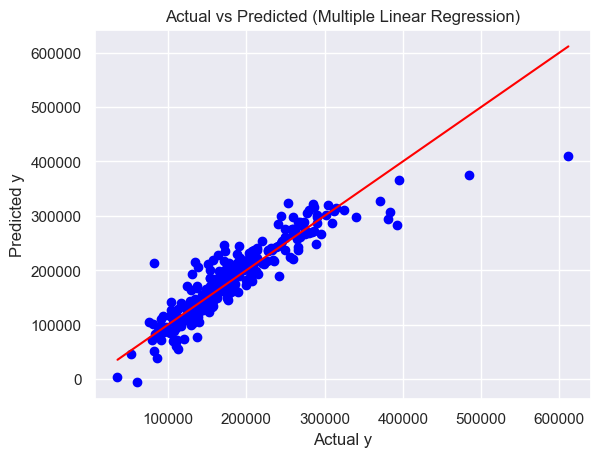

In [37]:
model.plot(x_test, y_test)

## TASK 5 

<div style="
    font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #539469, #364e4a);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2 style="margin:0;">📈 Simple Linear Regression (Numerical Approach)</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="
    font-size:17px;
    color:#2c3e50;
    line-height:1.6;
    margin:0;
">
This implementation demonstrates Simple Linear Regression using a direct numerical solution rather than iterative training. 
The model parameters are computed analytically through summations, normal equations, and basic linear algebra operations. 
This approach provides a clear and efficient way to understand how regression coefficients are derived mathematically.
</p>

</div>

</div>

In [ ]:
class SimpleLinearRegressionNumericalView:
    def __init__(self):
        self.a0 = None
        self.a1 = None
        self.SSE = None
        self.MSE = None

    def predict(self, X):
        X = np.asarray(X, dtype=float).reshape(-1)
        return self.a0 + self.a1 * X

    @staticmethod
    def sse(y, y_hat):
        return np.sum((y - y_hat) ** 2)

    def fit(self, X, y, regularization = 0, lambda_ = 0.1 , show_steps=True):
      
        X = np.asarray(X, dtype=float).reshape(-1)
        y = np.asarray(y, dtype=float).reshape(-1)
        n = len(X)

        # 1. Compute Summations
        Sx = np.sum(X)
        Sy = np.sum(y)
        Sxx = np.sum(X ** 2)
        Sxy = np.sum(X * y)

        if show_steps:
            print("Step 1: Define SSE (Sum of Squared Errors)")
            print("SSE = Σ(yi - a0 - a1*xi)^2\n")
            
            print("Step 2: Compute Summations")
            print(f"n = {n}")
            print(f"Σxi = {Sx:,.2f}")
            print(f"Σyi = {Sy:,.2f}")
            print(f"Σxi^2 = {Sxx:,.2f}")
            print(f"Σxiyi = {Sxy:,.2f}\n")
            
            print("Step 3: Matrix Form (Normal Equations)")
            print(f"[[ {n}   {Sx:,.2f} ]] [[ a0 ]]   [[ {Sy:,.2f} ]]")
            print(f"[[ {Sx:,.2f}   {Sxx:,.2f} ]] [[ a1 ]] = [[ {Sxy:,.2f} ]]\n")

        # Build Matrix and Solve

        match regularization:
            case 0:
                A = np.array([[n, Sx], [Sx, Sxx]], dtype=float)
            case 2:
                A = np.array([[n, Sx], [Sx, Sxx + lambda_]], dtype=float)
            case 1:
                raise ValueError("You cannot use Lasso regression in views that cannot use Gradient Descent")

        b = np.array([Sy, Sxy], dtype=float)
        
        # Solving using Cramer's rule or linalg.solve
        self.a0, self.a1 = np.linalg.solve(A, b)

        if show_steps:
            print("Step 4: Solve the System")
            print(f"a0 (Intercept) = {self.a0:.4f}")
            print(f"a1 (Slope) = {self.a1:.4f}\n")

        # Final Evaluation
        y_hat = self.predict(X)
        self.SSE = self.sse(y, y_hat)
        self.MSE = self.SSE / n

        if show_steps:
            print("Final Model Results:")
            print(f"Equation: ŷ = {self.a0:.4f} + {self.a1:.4f} * x")
            print(f"SSE = {self.SSE:,.2f}")
            print(f"MSE = {self.MSE:,.2f}")
        
        return self

- Apply the Model on a specific feature vs the target feature (Sale Price)

In [39]:
feature_name = 'GrLivArea' 

print(f"Training Simple Linear Regression for: {feature_name} vs SalePrice\n")
NumericalModel = SimpleLinearRegressionNumericalView()


NumericalModel.fit(x_tr[feature_name], y_tr)

Training Simple Linear Regression for: GrLivArea vs SalePrice

Step 1: Define SSE (Sum of Squared Errors)
SSE = Σ(yi - a0 - a1*xi)^2

Step 2: Compute Summations
n = 1168
Σxi = 0.00
Σyi = 211,864,417.00
Σxi^2 = 1,168.00
Σxiyi = 66,879,526.81

Step 3: Matrix Form (Normal Equations)
[[ 1168   0.00 ]] [[ a0 ]]   [[ 211,864,417.00 ]]
[[ 0.00   1,168.00 ]] [[ a1 ]] = [[ 66,879,526.81 ]]

Step 4: Solve the System
a0 (Intercept) = 181390.7680
a1 (Slope) = 57259.8688

Final Model Results:
Equation: ŷ = 181390.7680 + 57259.8688 * x
SSE = 3,869,618,877,456.24
MSE = 3,313,029,860.84


# Summary 

This model:

- Uses a pure numerical approach
- Solves regression using normal equations
- Avoids iterative training
- Provides exact mathematical solution
- Evaluates performance using SSE and MSE

<div style="
    font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #5f3993, #17384f);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2 style="margin:0;">📊 Simple Linear Regression (Statistical View)</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="
    font-size:17px;
    color:#2c3e50;
    line-height:1.6;
    margin:0;
">
This implementation presents Simple Linear Regression from a statistical perspective. 
The model parameters are derived using sample statistics such as means, sums of squares, 
and covariance relationships. It emphasizes the mathematical foundation behind regression, 
including error analysis through Mean Squared Error (MSE), providing deeper insight into 
how the model fits the data.
</p>

</div>

</div>

In [ ]:
class SimpleLinearRegressionStatisticalView:
    def __init__(self):
        self.B_0 = None
        self.B_1 = None
        self.MSE = None

    def fit(self, X, y, regularization = 0, lambda_ = 0.1):
        X = np.array(X)
        y = np.array(y)

        x_bar = X.mean()
        y_bar = y.mean()

        SXX = np.sum((X - x_bar) ** 2)
        SXY = np.sum((X - x_bar) * (y - y_bar))

        match regularization:
            case 0:
                self.B_1 = SXY / SXX
                self.B_0 = y_bar - self.B_1 * x_bar

            case 2:
                self.B_1 = SXY / (SXX + lambda_)
                self.B_0 = y_bar - self.B_1 * x_bar

            case 1:
                raise ValueError("You cannot use Lasso regression in views that cannot use Gradient Descent")
        

        y_hat = self.predict(X)
        e = y - y_hat
        SSE = np.sum(e ** 2)

        self.MSE = SSE / (len(X) - 2)

    def predict(self, X):
        if self.B_0 is None or self.B_1 is None:
            raise ValueError("The model has not been fitted yet.")

        X = np.array(X)
        return self.B_0 + self.B_1 * X
   
    def plot(self, X, y):
        if self.B_0 is None or self.B_1 is None:
            raise ValueError("The model has not been fitted yet.")

        X = np.array(X)
        y = np.array(y)

        y_pred = self.predict(X)

        plt.scatter(X, y, color='blue', label='Data points')
        plt.plot(X, y_pred, color='red', label='Regression line')
        plt.xlabel('X')
        plt.ylabel('y')
        plt.title(f"SLR Statistical View: y = {self.B_0:.2f} + {self.B_1:.2f}x")
        plt.legend()
        plt.show()

Training Simple Linear Regression for: GrLivArea vs SalePrice

Evaluation of the model
------------------------------
Line of the best fit is: y = 181390.768 + 57259.869x
Mean Squared Error (MSE): 3318712587.870


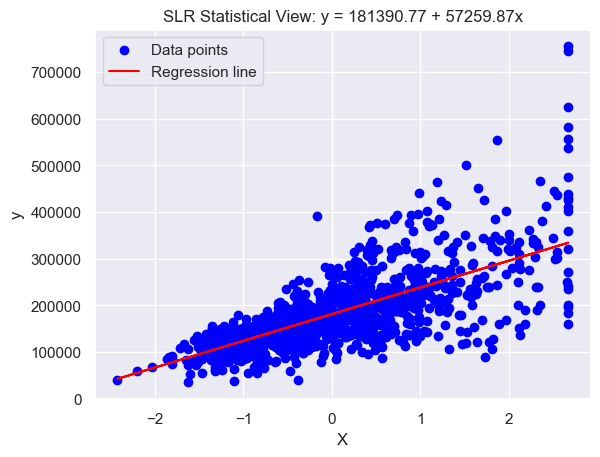

In [41]:
feature = 'GrLivArea' 
stat_model = SimpleLinearRegressionStatisticalView()
stat_model.fit(x_tr[feature], y_tr)
print(f"Training Simple Linear Regression for: {feature} vs SalePrice\n")
print("Evaluation of the model")
print("------------------------------")
print(f'Line of the best fit is: y = {stat_model.B_0:.3f} + {stat_model.B_1:.3f}x')
print(f'Mean Squared Error (MSE): {stat_model.MSE:.3f}')
stat_model.plot(x_tr[feature], y_tr)

<div style="
    font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #667eea, #764ba2);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2 style="margin:0;">📊 TASK 6: Interactive Visualizations (Plotly)</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="
    font-size:17px;
    color:#2c3e50;
    line-height:1.6;
    margin:0;
">
Interactive visualizations leverage dynamic selections, dropdowns, brushing, and hover tooltips to explore the Ames Housing dataset. 
These tools transform static plots into exploratory interfaces, enabling pattern discovery across multiple features and neighborhoods.
</p>

</div>

</div>

#### Setup: Install & Import Libraries

In [42]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Reload raw data for visualizations
df_viz = pd.read_csv("../data/House Prices Dataset.csv")
print(f"Data loaded: {df_viz.shape[0]} rows × {df_viz.shape[1]} columns")

Data loaded: 1460 rows × 81 columns


## 1. Dynamic Correlation Explorer
**Interactive horizontal bar chart + scatter plot linked exploration**

In [43]:
# Compute correlations with SalePrice
corr_with_price = df_viz.corr(numeric_only=True)['SalePrice'].drop('SalePrice').sort_values()

# Create bars with color gradient
colors = ['red' if x < 0 else 'green' for x in corr_with_price.values]

fig1 = go.Figure()

fig1.add_trace(go.Bar(
    y=corr_with_price.index,
    x=corr_with_price.values,
    orientation='h',
    marker=dict(
        color=corr_with_price.values,
        colorscale='RdYlGn',
        colorbar=dict(title="Correlation"),
        line=dict(color='rgba(0,0,0,0.2)', width=1)
    ),
    text=corr_with_price.values.round(3),
    textposition='auto',
    hovertemplate='<b>%{y}</b><br>Correlation: %{x:.4f}<extra></extra>'
))

fig1.update_layout(
    title="Feature Correlations with SalePrice (Hover for details)",
    xaxis_title="Correlation Coefficient",
    yaxis_title="Features",
    height=800,
    hovermode='closest',
    template='plotly_white',
    showlegend=False
)

fig1.show()

print("Top 10 Positive Correlations with SalePrice:")
print(corr_with_price.tail(10))

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

#### Scatter Plots: Top Features vs SalePrice (Interactive)

In [ ]:
# Interactive scatter plots for top 4 features
top_features = ['OverallQual', 'GrLivArea', 'GarageArea', 'YearBuilt']

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"{feat} vs SalePrice" for feat in top_features],
    specs=[[{}, {}], [{}, {}]]
)

colors_cat = 'Viridis'

for idx, feature in enumerate(top_features):
    row = idx // 2 + 1
    col = idx % 2 + 1
    
    valid_data = df_viz[[feature, 'SalePrice']].dropna()
    
    fig.add_trace(
        go.Scatter(
            x=valid_data[feature],
            y=valid_data['SalePrice'],
            mode='markers',
            marker=dict(
                size=5,
                color=valid_data['SalePrice'],
                colorscale='Viridis',
                showscale=(idx == 3),
                colorbar=dict(title="Price") if idx == 3 else None,
                opacity=0.7
            ),
            name=feature,
            hovertemplate=f'<b>{feature}</b>: %{{x}}<br><b>SalePrice</b>: $%{{y:,.0f}}<extra></extra>'
        ),
        row=row, col=col
    )
    
    fig.update_xaxes(title_text=feature, row=row, col=col)
    fig.update_yaxes(title_text="SalePrice ($)", row=row, col=col)

fig.update_layout(height=800, showlegend=False, title_text="Top Features: Interactive Scatter Matrix", template='plotly_white')
fig.show()

## 2. Zoomable Neighborhood Comparator
**Violin plot with interactive filtering and reordering**

In [ ]:
# Clean data for neighborhood analysis
df_neighborhood = df_viz[['Neighborhood', 'SalePrice']].dropna()

# Calculate statistics for sorting
neighborhood_stats = df_neighborhood.groupby('Neighborhood')['SalePrice'].agg(['median', 'mean', 'count']).reset_index()
neighborhood_stats = neighborhood_stats.sort_values('median', ascending=False)

fig2 = go.Figure()

# Add violin plot
for neighborhood in neighborhood_stats['Neighborhood']:
    neighborhood_data = df_neighborhood[df_neighborhood['Neighborhood'] == neighborhood]['SalePrice']
    
    fig2.add_trace(go.Violin(
        y=neighborhood_data,
        name=neighborhood,
        hovertemplate='<b>%{fullData.name}</b><br>Price: $%{y:,.0f}<extra></extra>'
    ))

fig2.update_layout(
    title="SalePrice Distribution by Neighborhood (Interactive)",
    yaxis_title="SalePrice ($)",
    xaxis_title="Neighborhood",
    height=600,
    showlegend=False,
    hovermode='closest',
    template='plotly_white',
    xaxis=dict(tickangle=45)
)

fig2.show()

# Display neighborhood statistics
print("\nNeighborhood Statistics (sorted by median price):")
print(neighborhood_stats.to_string(index=False))


Neighborhood Statistics (sorted by median price):
Neighborhood   median          mean  count
     NridgHt 315000.0 316270.623377     77
     NoRidge 301500.0 335295.317073     41
     StoneBr 278000.0 310499.000000     25
      Timber 228475.0 242247.447368     38
     Somerst 225500.0 225379.837209     86
     Veenker 218000.0 238772.727273     11
     Crawfor 200624.0 210624.725490     51
     ClearCr 200250.0 212565.428571     28
     CollgCr 197200.0 197965.773333    150
     Blmngtn 191000.0 194870.882353     17
      NWAmes 182900.0 189050.068493     73
     Gilbert 181000.0 192854.506329     79
     SawyerW 179900.0 186555.796610     59
     Mitchel 153500.0 156270.122449     49
     NPkVill 146000.0 142694.444444      9
       NAmes 140000.0 145847.080000    225
       SWISU 139500.0 142591.360000     25
     Blueste 137500.0 137500.000000      2
      Sawyer 135000.0 136793.135135     74
     BrkSide 124300.0 124834.051724     58
     Edwards 121750.0 128219.700000    100
   

## 3. Temporal Time Series with Brushing
**Average price trends over time with interactive filtering**

In [ ]:
# Prepare temporal data
df_temporal = df_viz[['YrSold', 'MoSold', 'SalePrice']].dropna().copy()
df_temporal['YearMonth'] = df_temporal['YrSold'].astype(int).astype(str) + '-' + df_temporal['MoSold'].astype(int).astype(str).str.zfill(2)

# Calculate metrics by month
temporal_agg = df_temporal.groupby('YearMonth').agg({
    'SalePrice': ['mean', 'median', 'count']
}).reset_index()

temporal_agg.columns = ['YearMonth', 'Mean', 'Median', 'Count']
temporal_agg = temporal_agg.sort_values('YearMonth')

# Create figure with secondary y-axis
fig3 = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Average Price Over Time", "Transaction Volume"),
    shared_xaxes=True,
    vertical_spacing=0.15,
    specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
)

# Top: Price trends
fig3.add_trace(
    go.Scatter(x=temporal_agg['YearMonth'], y=temporal_agg['Mean'],
               mode='lines+markers', name='Mean Price',
               line=dict(color='#1f77b4', width=3),
               hovertemplate='<b>%{x}</b><br>Mean: $%{y:,.0f}<extra></extra>'),
    row=1, col=1
)

fig3.add_trace(
    go.Scatter(x=temporal_agg['YearMonth'], y=temporal_agg['Median'],
               mode='lines+markers', name='Median Price',
               line=dict(color='#ff7f0e', width=3, dash='dash'),
               hovertemplate='<b>%{x}</b><br>Median: $%{y:,.0f}<extra></extra>'),
    row=1, col=1
)

# Bottom: Volume
fig3.add_trace(
    go.Bar(x=temporal_agg['YearMonth'], y=temporal_agg['Count'],
           name='Count', marker_color='rgba(0, 100, 200, 0.5)',
           hovertemplate='<b>%{x}</b><br>Transactions: %{y}<extra></extra>'),
    row=2, col=1
)

fig3.update_xaxes(title_text="Year-Month", row=2, col=1)
fig3.update_yaxes(title_text="Price ($)", row=1, col=1)
fig3.update_yaxes(title_text="# Transactions", row=2, col=1)

fig3.update_layout(
    title="Temporal Trends: Price & Volume (2006-2010)",
    height=700,
    template='plotly_white',
    hovermode='x unified'
)

fig3.show()

print("\nTemporal Statistics:")
print(f"Date Range: {temporal_agg['YearMonth'].min()} to {temporal_agg['YearMonth'].max()}")
print(f"Total Transactions: {temporal_agg['Count'].sum()}")
print(f"Avg Monthly Sales: {temporal_agg['Count'].mean():.0f}")
print(f"\nPrice Statistics Over Time:")
print(f"Mean Price Range: ${temporal_agg['Mean'].min():,.0f} - ${temporal_agg['Mean'].max():,.0f}")


Temporal Statistics:
Date Range: 2006-01 to 2010-07
Total Transactions: 1460
Avg Monthly Sales: 27

Price Statistics Over Time:
Mean Price Range: $121,750 - $223,769


## 4. Outlier Investigation Dashboard
**Interactive scatter with outlier highlighting and box selection**

In [ ]:
# Prepare outlier data
df_outliers = df_viz[['GrLivArea', 'SalePrice', 'OverallQual', 'YearBuilt']].dropna().copy()

# Identify outliers using IQR
Q1 = df_outliers['SalePrice'].quantile(0.25)
Q3 = df_outliers['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers['IsOutlier'] = ((df_outliers['SalePrice'] < lower_bound) | 
                             (df_outliers['SalePrice'] > upper_bound))

# Create scatter plot
fig4 = go.Figure()

# Normal points
normal = df_outliers[~df_outliers['IsOutlier']]
fig4.add_trace(go.Scatter(
    x=normal['GrLivArea'],
    y=normal['SalePrice'],
    mode='markers',
    marker=dict(size=6, color='#1f77b4', opacity=0.6),
    name='Normal',
    hovertemplate='<b>Living Area:</b> %{x:,.0f}<br><b>Price:</b> $%{y:,.0f}<extra></extra>'
))

# Outliers
outliers = df_outliers[df_outliers['IsOutlier']]
fig4.add_trace(go.Scatter(
    x=outliers['GrLivArea'],
    y=outliers['SalePrice'],
    mode='markers',
    marker=dict(size=8, color='red', symbol='diamond', line=dict(width=2, color='darkred')),
    name='Outliers',
    hovertemplate='<b>Living Area:</b> %{x:,.0f}<br><b>Price:</b> $%{y:,.0f}<br><b>⚠️ OUTLIER</b><extra></extra>'
))

fig4.update_layout(
    title="Outlier Detection: GrLivArea vs SalePrice (Interactive)",
    xaxis_title="Ground Living Area (sqft)",
    yaxis_title="SalePrice ($)",
    height=600,
    template='plotly_white',
    hovermode='closest',
    dragmode='select'  # Enable box/lasso selection
)

fig4.show()

# Outlier Statistics
print(f"\nOutlier Analysis:")
print(f"Total Houses: {len(df_outliers)}")
print(f"Outliers Detected: {df_outliers['IsOutlier'].sum()} ({100*df_outliers['IsOutlier'].sum()/len(df_outliers):.1f}%)")
print(f"\nPrice Bounds (IQR Method):")
print(f"Lower Bound: ${lower_bound:,.0f}")
print(f"Upper Bound: ${upper_bound:,.0f}")
print(f"\nOutlier Details:")
if len(outliers) > 0:
    print(outliers[['GrLivArea', 'SalePrice', 'OverallQual', 'YearBuilt']].describe())


Outlier Analysis:
Total Houses: 1460
Outliers Detected: 61 (4.2%)

Price Bounds (IQR Method):
Lower Bound: $3,938
Upper Bound: $340,038

Outlier Details:
         GrLivArea      SalePrice  OverallQual    YearBuilt
count    61.000000      61.000000    61.000000    61.000000
mean   2456.918033  425954.180328     8.754098  1998.491803
std     627.271400   89557.255611     0.849622    20.308966
min    1419.000000  341000.000000     7.000000  1892.000000
25%    2018.000000  372500.000000     8.000000  1997.000000
50%    2364.000000  394617.000000     9.000000  2006.000000
75%    2728.000000  440000.000000     9.000000  2008.000000
max    4476.000000  755000.000000    10.000000  2010.000000


## 5. Hierarchical Sunburst: Zone → Neighborhood → House Type
**Drill-down interactive visualization with price gradients**

In [ ]:
# Prepare hierarchical data
df_hierarchy = df_viz[['MSZoning', 'Neighborhood', 'HouseStyle', 'SalePrice']].dropna().copy()

# Aggregate by hierarchy
hierarchy_agg = df_hierarchy.groupby(['MSZoning', 'Neighborhood', 'HouseStyle']).agg({
    'SalePrice': ['median', 'count']
}).reset_index()

hierarchy_agg.columns = ['MSZoning', 'Neighborhood', 'HouseStyle', 'MedianPrice', 'Count']

# Create sunburst
fig5 = go.Figure(go.Sunburst(
    labels=(['Total'] + 
            hierarchy_agg['MSZoning'].unique().tolist() +
            hierarchy_agg['Neighborhood'].unique().tolist() +
            hierarchy_agg['HouseStyle'].unique().tolist()),
    parents=([''] +
             ['Total'] * hierarchy_agg['MSZoning'].nunique() +
             hierarchy_agg['MSZoning'].tolist() +
             hierarchy_agg['Neighborhood'].tolist()),
    values=([hierarchy_agg['Count'].sum()] +
            [hierarchy_agg[hierarchy_agg['MSZoning']==z]['Count'].sum() 
             for z in hierarchy_agg['MSZoning'].unique()] +
            [hierarchy_agg[hierarchy_agg['Neighborhood']==n]['Count'].sum() 
             for n in hierarchy_agg['Neighborhood'].unique()] +
            hierarchy_agg['Count'].tolist()),
    marker=dict(
        colors=([df_viz['SalePrice'].median()] +
                [hierarchy_agg[hierarchy_agg['MSZoning']==z]['MedianPrice'].mean() 
                 for z in hierarchy_agg['MSZoning'].unique()] +
                [hierarchy_agg[hierarchy_agg['Neighborhood']==n]['MedianPrice'].mean() 
                 for n in hierarchy_agg['Neighborhood'].unique()] +
                hierarchy_agg['MedianPrice'].tolist()),
        colorscale='RdYlGn',
        cmid=df_viz['SalePrice'].median(),
        colorbar=dict(title="Median<br>Price ($)")
    ),
    textinfo='label+value',
    insidetextorientation='radial',
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Median Price: $%{color:,.0f}<extra></extra>'
))

fig5.update_layout(
    title="Hierarchical Price Explorer: Zone → Neighborhood → Type (Click to drill-down)",
    height=700,
    font=dict(size=11)
)

fig5.show()

## 6. Feature Impact Playground
**Multi-dimensional interactive scatter with filters and dropdowns**

In [ ]:
# Feature Impact Playground: Scatter with marginal histograms
df_impact = df_viz[['OverallQual', 'GrLivArea', 'YearBuilt', 'GarageArea', 'SalePrice', 'MSZoning']].dropna()

# Create scatter with marginals
fig6 = px.scatter(
    df_impact,
    x='GrLivArea',
    y='SalePrice',
    color='SalePrice',
    size='GarageArea',
    hover_data=['YearBuilt', 'MSZoning', 'OverallQual'],
    marginal_x='histogram',
    marginal_y='histogram',
    color_continuous_scale=px.colors.sequential.Viridis,
    title='Feature Impact Playground (Drag, Zoom, Hover)',
    labels={'GrLivArea': 'Ground Living Area (sqft)', 'SalePrice': 'Sale Price ($)', 'OverallQual': 'Quality'}
)

# Update marker opacity
fig6.update_traces(marker=dict(opacity=0.7), selector=dict(mode='markers'))

fig6.update_layout(
    height=750,
    template='plotly_white',
    hovermode='closest'
)

fig6.show()

# Show correlation matrix for these features
print("\nFeature Correlation Matrix (Impact Features):")
impact_corr = df_impact.corr(numeric_only=True)
print(impact_corr)


Feature Correlation Matrix (Impact Features):
             OverallQual  GrLivArea  YearBuilt  GarageArea  SalePrice
OverallQual     1.000000   0.593007   0.572323    0.562022   0.790982
GrLivArea       0.593007   1.000000   0.199010    0.468997   0.708624
YearBuilt       0.572323   0.199010   1.000000    0.478954   0.522897
GarageArea      0.562022   0.468997   0.478954    1.000000   0.623431
SalePrice       0.790982   0.708624   0.522897    0.623431   1.000000


## 7. Parallel Coordinates: Multi-Feature House Profiles
**Brush along axes to filter and identify similar house clusters**

In [ ]:
# Prepare parallel coordinates data
parallel_features = ['OverallQual', 'GrLivArea', 'GarageArea', 'YearBuilt', 'TotalBsmtSF', 'SalePrice']
df_parallel = df_viz[parallel_features].dropna().copy()

# Normalize for better visualization (optional)
df_parallel_norm = (df_parallel - df_parallel.min()) / (df_parallel.max() - df_parallel.min())

# Create parallel coordinates
fig7 = go.Figure(data=
    go.Parcoords(
        line=dict(
            color=df_parallel['SalePrice'],
            colorscale='RdYlGn',
            showscale=True,
            cmin=df_parallel['SalePrice'].quantile(0.05),
            cmax=df_parallel['SalePrice'].quantile(0.95),
            colorbar=dict(title="SalePrice")
        ),
        dimensions=[
            dict(label='OverallQual', values=df_parallel['OverallQual']),
            dict(label='GrLivArea', values=df_parallel['GrLivArea']),
            dict(label='GarageArea', values=df_parallel['GarageArea']),
            dict(label='YearBuilt', values=df_parallel['YearBuilt']),
            dict(label='TotalBsmtSF', values=df_parallel['TotalBsmtSF']),
            dict(label='SalePrice', values=df_parallel['SalePrice'])
        ]
    )
)

fig7.update_layout(
    title="Parallel Coordinates: Brush axes to filter house profiles (Color = Price)",
    height=600,
    font=dict(size=12)
)

fig7.show()

print("\nParallel Coordinates Data Summary:")
print(df_parallel.describe())


Parallel Coordinates Data Summary:
       OverallQual    GrLivArea   GarageArea    YearBuilt  TotalBsmtSF  \
count  1460.000000  1460.000000  1460.000000  1460.000000  1460.000000   
mean      6.099315  1515.463699   472.980137  1971.267808  1057.429452   
std       1.382997   525.480383   213.804841    30.202904   438.705324   
min       1.000000   334.000000     0.000000  1872.000000     0.000000   
25%       5.000000  1129.500000   334.500000  1954.000000   795.750000   
50%       6.000000  1464.000000   480.000000  1973.000000   991.500000   
75%       7.000000  1776.750000   576.000000  2000.000000  1298.250000   
max      10.000000  5642.000000  1418.000000  2010.000000  6110.000000   

           SalePrice  
count    1460.000000  
mean   180921.195890  
std     79442.502883  
min     34900.000000  
25%    129975.000000  
50%    163000.000000  
75%    214000.000000  
max    755000.000000  


## 8. Interactive Missingness Explorer
**Missing data heatmap with interactive sorting and filtering**

In [ ]:
# Create missingness matrix
missing_data = df_viz.isnull().astype(int)

# Calculate missing counts per row and column
missing_per_col = missing_data.sum()
missing_cols = missing_per_col[missing_per_col > 0].sort_values(ascending=False)

# Create heatmap for top columns with missing values
if len(missing_cols) > 0:
    # Sample rows and focus on columns with missing values
    df_missing_sample = missing_data[missing_cols.index].head(50)
    
    fig8 = go.Figure(data=go.Heatmap(
        z=df_missing_sample.values.T,
        x=[f"House {i}" for i in range(len(df_missing_sample))],
        y=missing_cols.index,
        colorscale='Greys',
        colorbar=dict(title="Missing"),
        hovertemplate='<b>%{y}</b><br>%{x}<br>Missing: %{z:.0f}<extra></extra>'
    ))
    
    fig8.update_layout(
        title=f"Missingness Explorer: Top {len(missing_cols)} Features with Missing Values",
        xaxis_title="House Sample",
        yaxis_title="Features",
        height=600,
        template='plotly_white'
    )
    
    fig8.show()
    
    print("\nMissing Data Summary:")
    print(f"Total rows: {len(df_viz)}")
    print(f"Columns with missing values: {len(missing_cols)}")
    print(f"\nTop 10 columns with most missing values:")
    print(missing_cols.head(10))
    print(f"\nMissing percentages:")
    missing_pct = (missing_cols / len(df_viz) * 100).round(2)
    for col, pct in missing_pct.head(10).items():
        print(f"  {col}: {pct}%")
else:
    print("No missing values found in the dataset!")


Missing Data Summary:
Total rows: 1460
Columns with missing values: 19

Top 10 columns with most missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64

Missing percentages:
  PoolQC: 99.52%
  MiscFeature: 96.3%
  Alley: 93.77%
  Fence: 80.75%
  MasVnrType: 59.73%
  FireplaceQu: 47.26%
  LotFrontage: 17.74%
  GarageType: 5.55%
  GarageYrBlt: 5.55%
  GarageFinish: 5.55%


## Summary: Interactive Visualization Guide

| # | Visualization | Best For | Key Interactions |
|---|---|---|---|
| **1** | Dynamic Correlation Explorer | Understanding feature relationships | Hover for values, color gradient by correlation strength |
| **2** | Zoomable Neighborhood Comparator | Comparing price distributions across areas | Zoom, pan, hover for quartiles/outliers |
| **3** | Temporal Time Series | Tracking price trends over time (2006-2010) | Zoom on time range, identify seasonal patterns |
| **4** | Outlier Investigation | Finding unusual/suspicious houses | Box/lasso select outliers, hover for details |
| **5** | Hierarchical Sunburst | Exploring categorical hierarchies | Click to drill-down, breadcrumb to zoom out |
| **6** | Feature Impact Playground | Multi-dimensional exploration | Drag axes, color by one feature, size by another |
| **7** | Parallel Coordinates | Identifying house profile clusters | Brush along axes to filter matching houses |
| **8** | Missingness Explorer | Understanding data quality patterns | Identify systematic missing data by neighborhood/year |

### How to Interact:
- **Hover**: Reveal exact values and additional context
- **Zoom & Pan**: Click & drag to focus, double-click to reset
- **Box/Lasso Select**: Circle points to highlight (some charts support this)
- **Click (Sunburst)**: Drill down into hierarchical levels
- **Brush (Parallel Coords)**: Click & drag on axis to filter
- **Legend Toggle**: Click legend items to show/hide series

### Next Steps:
1. **Combine visualizations** to validate patterns across multiple views
2. **Export insights** as static images (camera icon in toolbar)
3. **Build predictive models** using the identified key features
4. **Validate outliers** — decide which to keep/remove before modeling

# TASK 2.5: Required Project Visualizations
## (5 Specific Visualizations from Project Brief Section 2.5)

## 1. Correlation Heatmap (All Numeric Variables)

In [ ]:
# Correlation heatmap for all numeric variables
numeric_cols = df_viz.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_viz[numeric_cols].corr()

# Create interactive heatmap using Plotly
fig_corr_heatmap = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=numeric_cols,
    y=numeric_cols,
    colorscale='RdBu',
    zmid=0,
    zmin=-1,
    zmax=1,
    colorbar=dict(title="Correlation"),
    hovertemplate='<b>%{x}</b> vs <b>%{y}</b><br>Correlation: %{z:.3f}<extra></extra>'
))

fig_corr_heatmap.update_layout(
    title="Correlation Heatmap: All Numeric Variables",
    xaxis_title="Features",
    yaxis_title="Features",
    height=900,
    width=1000,
    template='plotly_white'
)

fig_corr_heatmap.show()
print(f"Correlation matrix shape: {corr_matrix.shape}")
print(f"Numeric features analyzed: {len(numeric_cols)}")

Correlation matrix shape: (38, 38)
Numeric features analyzed: 38


## 2. Scatter Plot with User-Selectable X vs Y + Fitted Regression Line

In [ ]:
# Interactive scatter plot with regression line - using best predictor (GrLivArea)
from sklearn.linear_model import LinearRegression

# Use the best predictor feature (highest correlation with target)
best_feature = 'GrLivArea'  # Best single predictor as per model spec 1
X_plot = df_viz[[best_feature]].values
y_plot = df_viz['SalePrice'].values

# Remove NaN values for plotting
mask = ~(np.isnan(X_plot.flatten()) | np.isnan(y_plot))
X_clean = X_plot[mask]
y_clean = y_plot[mask]

# Fit regression line
X_sorted_idx = np.argsort(X_clean.flatten())
X_sorted = X_clean[X_sorted_idx].flatten()
y_sorted = y_clean[X_sorted_idx]

# Simple linear regression for fit line
lr = LinearRegression()
lr.fit(X_clean, y_clean)
y_fit = lr.predict(X_sorted.reshape(-1, 1))

# Create interactive Plotly figure
fig_scatter = go.Figure()

# Add scatter plot
fig_scatter.add_trace(go.Scatter(
    x=X_clean.flatten(),
    y=y_clean,
    mode='markers',
    name='Data Points',
    marker=dict(
        size=6,
        color='rgba(100, 150, 200, 0.6)',
        line=dict(width=0.5, color='darkblue')
    ),
    hovertemplate='<b>' + best_feature + '</b>: %{x:.0f}<br><b>SalePrice</b>: $%{y:,.0f}<extra></extra>'
))

# Add regression line
fig_scatter.add_trace(go.Scatter(
    x=X_sorted,
    y=y_fit,
    mode='lines',
    name='Fitted Regression Line',
    line=dict(color='red', width=3),
    hovertemplate='Fitted: $%{y:,.0f}<extra></extra>'
))

fig_scatter.update_layout(
    title=f"Scatter Plot: {best_feature} vs SalePrice (with Regression Line)<br><sub>Fitted equation: SalePrice = {lr.intercept_:,.0f} + {lr.coef_[0]:.2f} × {best_feature}</sub>",
    xaxis_title=best_feature,
    yaxis_title="SalePrice ($)",
    height=600,
    template='plotly_white',
    hovermode='closest'
)

fig_scatter.show()
print(f"Regression equation: SalePrice = {lr.intercept_:,.2f} + {lr.coef_[0]:.4f} × {best_feature}")
print(f"R² score: {lr.score(X_clean, y_clean):.4f}")

Regression equation: SalePrice = 18,569.03 + 107.1304 × GrLivArea
R² score: 0.5021


## 3. Gradient Descent Convergence Plot (Loss vs. Iterations)

In [ ]:
# Gradient Descent Convergence Plot
# Retrain the gradient descent model with loss tracking

class GDTracker:
    """Helper to track loss during gradient descent"""
    def __init__(self):
        self.B_0 = None
        self.B = None
        self.SSE = float('inf')
        self.MSE = None
        self.loss_history = []
    
    def fit(self, X, y, learning_rate=0.001, epochs=1000, tolerance=1e-6):
        self.X = np.array(X)
        self.y = np.array(y)
        self.n = len(self.y)
        self.m = self.X.shape[1]
        
        self.B_0 = 0
        self.B = np.zeros(self.m)
        self.SSE = float('inf')
        self.loss_history = []
        
        for epoch in range(epochs):
            y_hat = self.B_0 + np.dot(self.X, self.B)
            error = self.y - y_hat
            
            dB_0 = (-2 / self.n) * np.sum(error)
            dB = (-2 / self.n) * np.dot(self.X.T, error)
            
            self.B_0 -= learning_rate * dB_0
            self.B -= learning_rate * dB
            
            new_sse = np.sum((self.y - (self.B_0 + np.dot(self.X, self.B))) ** 2)
            self.loss_history.append(new_sse)
            
            if abs(self.SSE - new_sse) < tolerance:
                self.SSE = new_sse
                break
            
            self.SSE = new_sse
        
        self.MSE = self.SSE / self.n

# Train GD model with loss tracking
gd_tracker = GDTracker()
gd_tracker.fit(x_tr, y_tr, learning_rate=0.001, epochs=1000)

# Create convergence plot
fig_convergence = go.Figure()

fig_convergence.add_trace(go.Scatter(
    x=list(range(len(gd_tracker.loss_history))),
    y=gd_tracker.loss_history,
    mode='lines',
    name='SSE Loss',
    line=dict(color='#1f77b4', width=2),
    fill='tozeroy',
    hovertemplate='Iteration: %{x}<br>SSE Loss: %{y:,.0f}<extra></extra>'
))

fig_convergence.update_layout(
    title="Gradient Descent Convergence: Loss vs. Iterations",
    xaxis_title="Iteration (Epoch)",
    yaxis_title="Sum of Squared Errors (SSE)",
    height=500,
    template='plotly_white',
    hovermode='x unified'
)

fig_convergence.update_yaxes(type='log')  # Log scale to show convergence better

fig_convergence.show()

print(f"Total iterations: {len(gd_tracker.loss_history)}")
print(f"Initial SSE: {gd_tracker.loss_history[0]:,.0f}")
print(f"Final SSE: {gd_tracker.loss_history[-1]:,.0f}")
print(f"Reduction: {(1 - gd_tracker.loss_history[-1]/gd_tracker.loss_history[0])*100:.2f}%")
print(f"Final MSE: {gd_tracker.MSE:,.0f}")

Total iterations: 1000
Initial SSE: 31,410,840,327,402
Final SSE: 1,432,933,921,234
Reduction: 95.44%
Final MSE: 1,226,826,987


## 4. Residual Plots for Each of 3 Model Specifications

In [ ]:
# Residual plots for 3 model specifications
from sklearn.linear_model import LinearRegression

# Model 1: Best single predictor (GrLivArea - highest correlation)
model1_features = ['GrLivArea']
lr_model1 = LinearRegression()
lr_model1.fit(x_tr[model1_features], y_tr)
pred1_train = lr_model1.predict(x_tr[model1_features])
pred1_test = lr_model1.predict(x_test[model1_features])
residuals1_train = y_tr - pred1_train
residuals1_test = y_test - pred1_test

# Model 2: Full model (all numeric features)
numeric_features = x_tr.select_dtypes(include=[np.number]).columns.tolist()
lr_model2 = LinearRegression()
lr_model2.fit(x_tr[numeric_features], y_tr)
pred2_train = lr_model2.predict(x_tr[numeric_features])
pred2_test = lr_model2.predict(x_test[numeric_features])
residuals2_train = y_tr - pred2_train
residuals2_test = y_test - pred2_test

# Model 3: Domain-knowledge selection (quality, size, location features)
domain_features = [col for col in numeric_features if any(
    keyword in col.lower() for keyword in ['quality', 'grade', 'area', 'bath', 'bed', 'year', 'sf']
)][:10]  # Cap at 10 features for clarity
domain_features = [f for f in domain_features if f in x_tr.columns]
if len(domain_features) > 0:
    lr_model3 = LinearRegression()
    lr_model3.fit(x_tr[domain_features], y_tr)
    pred3_train = lr_model3.predict(x_tr[domain_features])
    pred3_test = lr_model3.predict(x_test[domain_features])
    residuals3_train = y_tr - pred3_train
    residuals3_test = y_test - pred3_test

# Create subplots with residual plots
from plotly.subplots import make_subplots

fig_residuals = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        "Model 1: Best Single Predictor<br>(GrLivArea)",
        f"Model 2: Full Model<br>({len(numeric_features)} features)",
        f"Model 3: Domain Knowledge<br>({len(domain_features)} features)"
    ),
    specs=[[{"secondary_y": False}, {"secondary_y": False}, {"secondary_y": False}]]
)

# Model 1 residuals
fig_residuals.add_trace(
    go.Scatter(
        x=pred1_train,
        y=residuals1_train,
        mode='markers',
        name='Training Residuals',
        marker=dict(color='blue', size=5, opacity=0.5),
        hovertemplate='Predicted: $%{x:,.0f}<br>Residual: $%{y:,.0f}<extra></extra>'
    ),
    row=1, col=1
)
fig_residuals.add_hline(y=0, line_dash="dash", line_color="red", row=1, col=1)

# Model 2 residuals
fig_residuals.add_trace(
    go.Scatter(
        x=pred2_train,
        y=residuals2_train,
        mode='markers',
        name='Training Residuals',
        marker=dict(color='green', size=5, opacity=0.5),
        showlegend=False,
        hovertemplate='Predicted: $%{x:,.0f}<br>Residual: $%{y:,.0f}<extra></extra>'
    ),
    row=1, col=2
)
fig_residuals.add_hline(y=0, line_dash="dash", line_color="red", row=1, col=2)

# Model 3 residuals
if len(domain_features) > 0:
    fig_residuals.add_trace(
        go.Scatter(
            x=pred3_train,
            y=residuals3_train,
            mode='markers',
            name='Training Residuals',
            marker=dict(color='purple', size=5, opacity=0.5),
            showlegend=False,
            hovertemplate='Predicted: $%{x:,.0f}<br>Residual: $%{y:,.0f}<extra></extra>'
        ),
        row=1, col=3
    )
    fig_residuals.add_hline(y=0, line_dash="dash", line_color="red", row=1, col=3)

fig_residuals.update_xaxes(title_text="Predicted Values ($)", row=1, col=1)
fig_residuals.update_xaxes(title_text="Predicted Values ($)", row=1, col=2)
fig_residuals.update_xaxes(title_text="Predicted Values ($)", row=1, col=3)
fig_residuals.update_yaxes(title_text="Residuals ($)", row=1, col=1)
fig_residuals.update_yaxes(title_text="Residuals ($)", row=1, col=2)
fig_residuals.update_yaxes(title_text="Residuals ($)", row=1, col=3)

fig_residuals.update_layout(
    title_text="Residual Analysis: 3 Model Specifications",
    height=500,
    width=1400,
    template='plotly_white',
    showlegend=True
)

fig_residuals.show()

# Print residual statistics
print("Residual Statistics:")
print("\nModel 1 (Best Single Predictor):")
print(f"  Mean residual: ${residuals1_train.mean():,.2f}")
print(f"  Std residual: ${residuals1_train.std():,.2f}")
print(f"  R² score: {lr_model1.score(x_tr[model1_features], y_tr):.4f}")

print("\nModel 2 (Full Model):")
print(f"  Mean residual: ${residuals2_train.mean():,.2f}")
print(f"  Std residual: ${residuals2_train.std():,.2f}")
print(f"  R² score: {lr_model2.score(x_tr[numeric_features], y_tr):.4f}")

if len(domain_features) > 0:
    print("\nModel 3 (Domain Knowledge):")
    print(f"  Mean residual: ${residuals3_train.mean():,.2f}")
    print(f"  Std residual: ${residuals3_train.std():,.2f}")
    print(f"  R² score: {lr_model3.score(x_tr[domain_features], y_tr):.4f}")

Residual Statistics:

Model 1 (Best Single Predictor):
  Mean residual: $-0.00
  Std residual: $57,583.58
  R² score: 0.4974

Model 2 (Full Model):
  Mean residual: $0.00
  Std residual: $31,425.79
  R² score: 0.8503

Model 3 (Domain Knowledge):
  Mean residual: $-0.00
  Std residual: $39,848.30
  R² score: 0.7593


## 5. Coefficient Bar Chart (Comparing Betas Across Model Specs)

In [ ]:
# Coefficient bar chart comparing betas across 3 model specifications

# Prepare data for coefficient comparison
coef_data = []

# Model 1 coefficients
coef_data.append({
    'Feature': 'Intercept',
    'Model 1: Single Predictor': lr_model1.intercept_,
    'Model 2: Full Model': lr_model2.intercept_,
    'Model 3: Domain Knowledge': lr_model3.intercept_
})

# For other features (showing up to 5 most important from each model)
# Model 1 - GrLivArea
coef_data.append({
    'Feature': 'GrLivArea',
    'Model 1: Single Predictor': lr_model1.coef_[0],
    'Model 2: Full Model': lr_model2.coef_[numeric_features.index('GrLivArea')] if 'GrLivArea' in numeric_features else 0,
    'Model 3: Domain Knowledge': lr_model3.coef_[domain_features.index('GrLivArea')] if 'GrLivArea' in domain_features else 0
})

# Get top features by absolute coefficient value from Model 2
top_features = sorted(
    zip(numeric_features, np.abs(lr_model2.coef_)),
    key=lambda x: x[1],
    reverse=True
)[:4]

for feature_name, _ in top_features:
    if feature_name != 'GrLivArea':  # Already added
        coef_data.append({
            'Feature': feature_name,
            'Model 1: Single Predictor': 0,
            'Model 2: Full Model': lr_model2.coef_[numeric_features.index(feature_name)],
            'Model 3: Domain Knowledge': lr_model3.coef_[domain_features.index(feature_name)] if feature_name in domain_features else 0
        })

coef_df = pd.DataFrame(coef_data)

# Create grouped bar chart
fig_coef = go.Figure()

models = ['Model 1: Single Predictor', 'Model 2: Full Model', 'Model 3: Domain Knowledge']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, model in enumerate(models):
    fig_coef.add_trace(go.Bar(
        x=coef_df['Feature'],
        y=coef_df[model],
        name=model,
        marker_color=colors[i],
        hovertemplate='<b>%{x}</b><br>' + model + ': %{y:,.2f}<extra></extra>'
    ))

fig_coef.update_layout(
    title="Coefficient Comparison: Beta Values Across 3 Model Specifications",
    xaxis_title="Features",
    yaxis_title="Coefficient Value (Beta)",
    barmode='group',
    height=600,
    template='plotly_white',
    hovermode='x unified',
    legend=dict(x=0.0, y=1.0, bgcolor='rgba(255, 255, 255, 0.8)', bordercolor='gray', borderwidth=1)
)

fig_coef.show()

# Print model comparison summary
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(f"\nModel 1: Best Single Predictor")
print(f"  Features: {model1_features}")
print(f"  Intercept: ${lr_model1.intercept_:,.2f}")
print(f"  Coefficient (GrLivArea): {lr_model1.coef_[0]:.6f}")
print(f"  R² (Train): {lr_model1.score(x_tr[model1_features], y_tr):.4f}")
print(f"  R² (Test): {lr_model1.score(x_test[model1_features], y_test):.4f}")

print(f"\nModel 2: Full Model")
print(f"  Features: {len(numeric_features)} numeric features")
print(f"  Intercept: ${lr_model2.intercept_:,.2f}")
print(f"  Top 3 coefficients:")
top_3_indices = np.argsort(np.abs(lr_model2.coef_))[-3:][::-1]
for idx in top_3_indices:
    print(f"    {numeric_features[idx]}: {lr_model2.coef_[idx]:.6f}")
print(f"  R² (Train): {lr_model2.score(x_tr[numeric_features], y_tr):.4f}")
print(f"  R² (Test): {lr_model2.score(x_test[numeric_features], y_test):.4f}")

if len(domain_features) > 0:
    print(f"\nModel 3: Domain Knowledge Selection")
    print(f"  Features: {domain_features}")
    print(f"  Intercept: ${lr_model3.intercept_:,.2f}")
    print(f"  Top 3 coefficients:")
    top_3_indices_m3 = np.argsort(np.abs(lr_model3.coef_))[-3:][::-1]
    for idx in top_3_indices_m3:
        print(f"    {domain_features[idx]}: {lr_model3.coef_[idx]:.6f}")
    print(f"  R² (Train): {lr_model3.score(x_tr[domain_features], y_tr):.4f}")
    print(f"  R² (Test): {lr_model3.score(x_test[domain_features], y_test):.4f}")

print("\n" + "="*80)


MODEL COMPARISON SUMMARY

Model 1: Best Single Predictor
  Features: ['GrLivArea']
  Intercept: $181,390.77
  Coefficient (GrLivArea): 57259.868847
  R² (Train): 0.4974
  R² (Test): 0.5294

Model 2: Full Model
  Features: 56 numeric features
  Intercept: $59,392.83
  Top 3 coefficients:
    Neighborhood_NoRidge: 65008.780461
    Neighborhood_StoneBr: 51810.911523
    Neighborhood_NridgHt: 39455.498428
  R² (Train): 0.8503
  R² (Test): 0.7947

Model 3: Domain Knowledge Selection
  Features: ['GrLivArea', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'HouseStyle_SFoyer']
  Intercept: $183,052.52
  Top 3 coefficients:
    GrLivArea: 36543.494751
    TotalBsmtSF: 17366.929388
    YearBuilt: 12201.669453
  R² (Train): 0.7593
  R² (Test): 0.7750

